# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import r_regression

seed=40
np.random.seed(seed)

load the data

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # MODIFIED: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    # Find columns with missing values
    missing_cols = df[feature_cols].columns[df[feature_cols].isna().any()]

    # BEFORE imputation
    before_stats = df[missing_cols].agg(['median', 'std'])
    print("======== Before Imputation ========")
    print(before_stats)

    # perform KNN imputation
    impute = KNNImputer(n_neighbors=5)
    df[feature_cols] = impute.fit_transform(df[feature_cols])
    
    # AFTER imputation
    after_stats = df[missing_cols].agg(['median', 'std'])
    print("\n\n======== After Imputation ========")
    print(after_stats)
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

======== Before Imputation ========
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.085612      1.600000     16.300000
std          1.037115      0.389564       1.582807      0.706689      1.035228


======== After Imputation ========
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.035683      1.700000     16.300000
std          1.009275      0.372434       1.514955      0.694645      1.011012


The KNN imputation method preserves the median values across features, indicating that the central distribution of the data remains stable after imputation. However, the standard deviation decreases slightly for all features, suggesting that the imputation introduces a smoothing effect by replacing missing values with averages of neighboring samples. This reduces data variability while maintaining the overall structure of the dataset.

In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

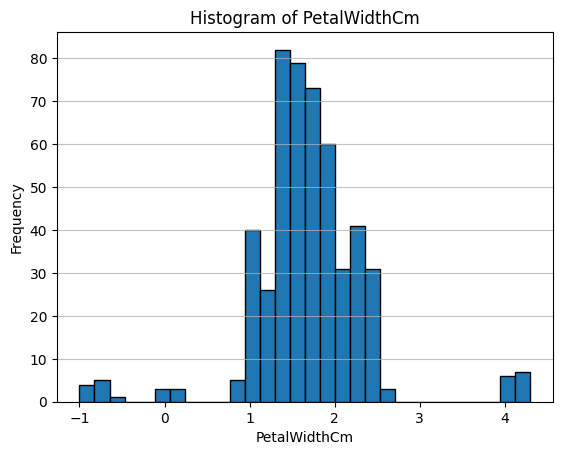

Correlation values:
 PetalWidthCompactness    0.991670
PetalWidthElongation     0.991551
PetalWidthCurvature      0.991273
PetalWidthMajorAxis      0.991141
PetalWidthSpread         0.991095
                           ...   
SepalWidthMinorAxis     -0.074392
SepalWidthCurvature     -0.081334
SepalWidthCompactness   -0.088496
SepalGlossIndex         -0.095200
SepalWidthMajorAxis     -0.096350
Length: 69, dtype: float64

The feature with the largest positive correlation with PetalWidthCm is: PetalWidthCompactness


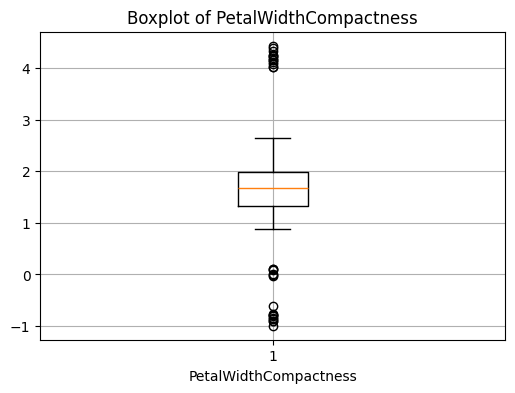

======== top 5 most negatively correlated features with PetalWidthCm ========
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64


/var/folders/fc/qgz_n4dd1tz286rp038s2nwm0000gn/T/ipykernel_60088/1989740391.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[neg_features], labels=neg_features)


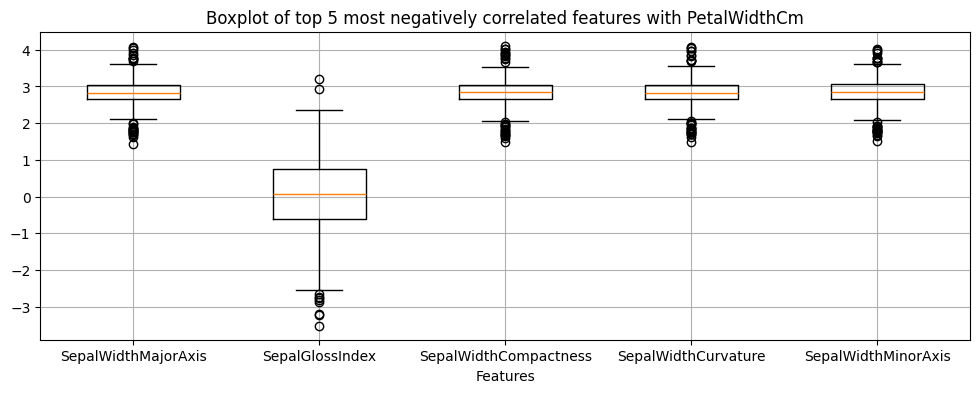

In [ ]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
# (a) plot histogram of the column "PetalWidthCm" 
plt.hist(df['PetalWidthCm'], bins=30, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# list the feature (excluding petalWidthCm, species and id) that has the largest positive correlation (Pearson correlation) with "PetalWidthCm"

# Define features and target
X = df.drop(columns=['PetalWidthCm', 'Species', 'Id'], errors='ignore')
y = df['PetalWidthCm']

# Compute Pearson correlations
r_values = r_regression(X, y)

# Convert to Series for easy handling
correlation = pd.Series(r_values, index=X.columns)

# Get feature with largest positive correlation
most_positive_corr_feature = correlation.idxmax()

print("Correlation values:\n", correlation.sort_values(ascending=False))
print(f"\nThe feature with the largest positive correlation with PetalWidthCm is: {most_positive_corr_feature}")

print("======== top 5 most negatively correlated features with PetalWidthCm ========")
neg_features = correlation.sort_values().head(5).index
print(correlation.sort_values().head(5))

# Single boxplot with 6 features: 1 most positive + top 5 most negative
selected_features = [most_positive_corr_feature] + [f for f in neg_features if f != most_positive_corr_feature]

plt.figure(figsize=(14, 5))
plt.boxplot(df[selected_features], labels=selected_features)
plt.title('Boxplot: most positive + top 5 most negative correlated features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.show()

## Model Training

### Prepare the data

In [7]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

In [8]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from model.metrics import evaluate_binary_classifier

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
# model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
# model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# # print model parameters
# print("Model parameters (weights):", model.W)
# # sum of absolute values of weights
# print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

def train_model(X_train, y_train, X_test, y_test, lr=0.1, reg_type = '', reg_lambda=0.0):
    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration =10000, val_ratio=0.2, reg_type='', reg_lambda=0.0)
    # print model parameters
    print("Model parameters (weights):", model.W)
    # sum of absolute values of weights
    print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)

### No Regularization

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.611179684417757
200. Training loss: 0.5636439627476497, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.49152377948438897, Val loss:0.5

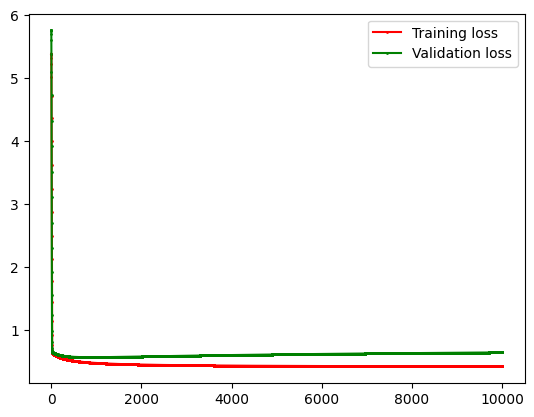

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

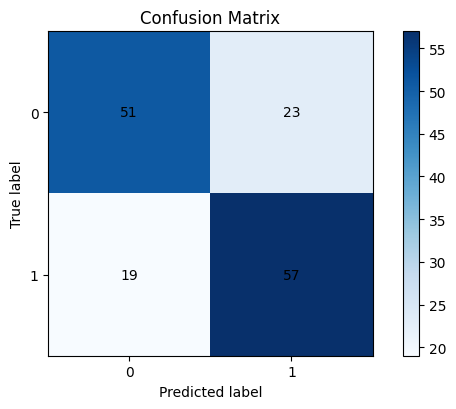

In [9]:
train_model(X_train, y_train, X_test, y_test, reg_type=None, reg_lambda=0.0)

### L2 Reg = 0.01

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.611179684417757
200. Training loss: 0.5636439627476497, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.49152377948438897, Val loss:0.5

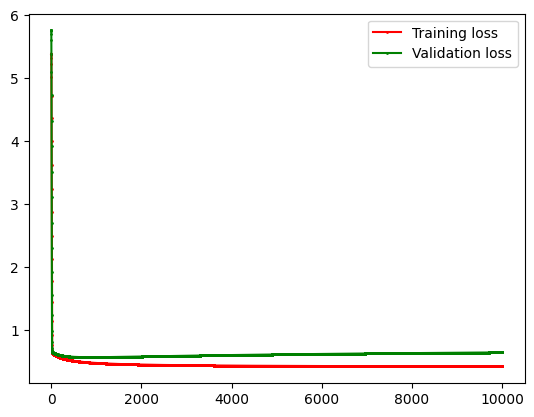

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

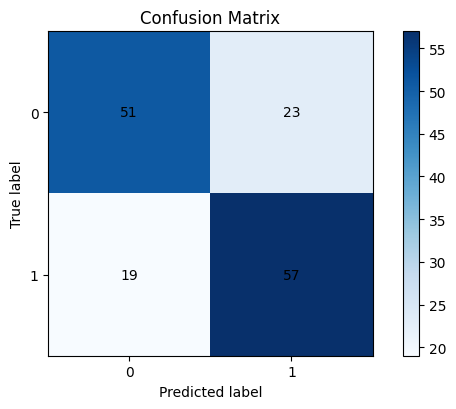

In [10]:
train_model(X_train, y_train, X_test, y_test, reg_type="l2", reg_lambda=0.01)

### L2 Reg = 1

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.611179684417757
200. Training loss: 0.5636439627476497, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.49152377948438897, Val loss:0.5

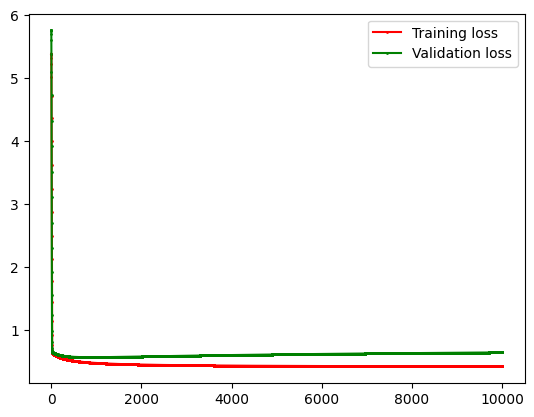

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

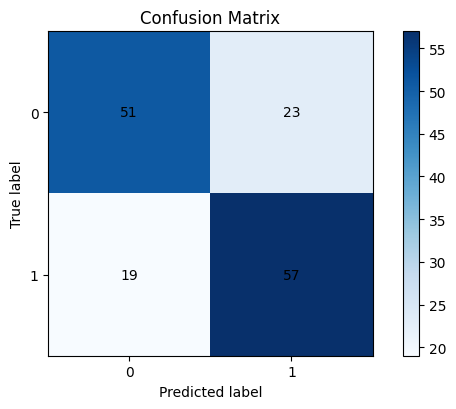

In [11]:
train_model(X_train, y_train, X_test, y_test, reg_type="l2", reg_lambda=1)

### L2 Reg = 100

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.611179684417757
200. Training loss: 0.5636439627476497, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.49152377948438897, Val loss:0.5

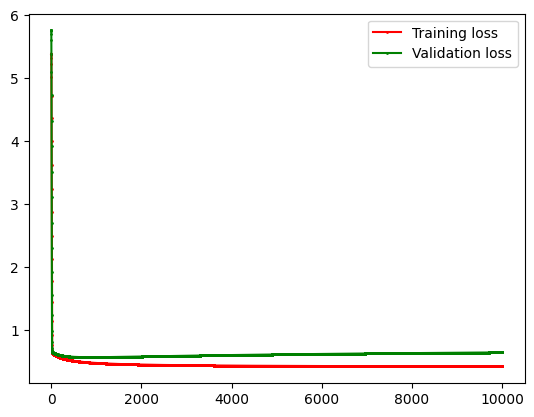

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

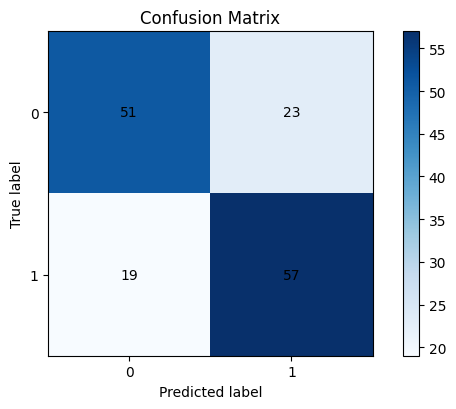

In [12]:
train_model(X_train, y_train, X_test, y_test, reg_type="l2", reg_lambda=100)

## Metrics

In [13]:
# # use evaluate_binary_classifier to evaluate the model on the test set
# from model.metrics import evaluate_binary_classifier

# y_pred = model.predict(X_test)
# evaluate_binary_classifier(y_test, y_pred)